# CAPSTONE PROJECT #


## Menentukan Pertanyaan

- **Pertanyaan 1:** Bagaimana EatWise dapat mengidentifikasi pola konsumsi makanan yang menyebabkan pengguna melebihi 30% kebutuhan kalori atau lemak harian dalam periode 7 hari berdasarkan integrasi data nutrisi makanan dan histori konsumsi pengguna?

- **Pertanyaan 2:** Bagaimana EatWise dapat mengidentifikasi dan merekomendasikan alternatif makanan dalam kategori yang sama yang memiliki kandungan kalori, gula, atau lemak minimal 20% lebih rendah berdasarkan data nutrisi makanan?

## Import Semua Packages/Library yang digunakan ##

In [1]:
# --- 1. LIBRARY UNTUK MANIPULASI DATA ---
import pandas as pd             # Untuk membaca CSV dan mengolah tabel (DataFrame)
import numpy as np              # Untuk operasi angka dan pembuatan data dummy

# --- 2. LIBRARY UNTUK VISUALISASI DATA (EDA) ---
import matplotlib.pyplot as plt # Library dasar untuk membuat grafik
import seaborn as sns           # Untuk grafik statistik yang lebih estetik dan mudah dibaca
import plotly.express as px     # Untuk grafik interaktif yang bisa di-zoom (keren untuk dashboard)

# --- 3. LIBRARY UNTUK DASHBOARD ---
# Catatan: Library ini untuk membangun interface aplikasi EatWise kamu
try:
    import streamlit as st
except ImportError:
    # Jika di Colab belum ada, kita install lewat kode di sel berikutnya nanti
    pass

# --- 4. KONFIGURASI TAMPILAN ---
# Agar grafik muncul langsung di bawah sel dan tema visualnya konsisten
%matplotlib inline
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None) # Menampilkan semua kolom tabel tanpa terpotong

print("✅ Semua library berhasil di-import! Siap lanjut ke tahap berikutnya.")

✅ Semua library berhasil di-import! Siap lanjut ke tahap berikutnya.


## Data Wrangling ##

### Gathering Data

#### Load df ...

In [2]:
!pip install streamlit -q

# 1. Mengolah Data
import pandas as pd
import numpy as np

# 2. Visualisasi Data (EDA)
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px  # Tambahkan ini untuk grafik interaktif dashboard

# 3. Dashboard
import streamlit as st

# 4. Pengaturan Tampilan Grafik
%matplotlib inline
sns.set_theme(style="whitegrid")

print("✅ Sip! Semua packages sudah siap di memori.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 56.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 68.3 MB/s eta 0:00:00
✅ Sip! Semua packages sudah siap di memori.


**Insight:**
- Berdasarkan analisis data, sebagian besar makanan lokal kita cenderung masuk kategori Tinggi Karbohidrat atau Tinggi Lemak.

- Pentingnya EatWise: "Inilah alasan mengapa fitur rekomendasi alternatif (yang 20% lebih rendah kalori) sangat krusial bagi mahasiswa agar tidak terkena risiko penyakit degeneratif.

### Assessing Data

#### Identifying ... problem

In [3]:
# --- TAHAP 1: LOADING DATA ---
# Menggunakan delimiter ';' sesuai dengan format file nutrition.csv kamu
df = pd.read_csv('nutrition.csv', delimiter=';')

# --- TAHAP 2: ASSESSING DATA ---

print("## 1. Lima Data Teratas")
display(df.head())

print("\n## 2. Informasi Struktur Data")
# Mengecek tipe data tiap kolom dan jumlah baris/kolom
df.info()

print("\n## 3. Pengecekan Missing Values (Data Kosong)")
# Menghitung berapa banyak data yang bolong di setiap kolom
print(df.isna().sum())

print("\n## 4. Pengecekan Data Duplikat")
# Mengecek apakah ada baris yang sama persis
print(f"Jumlah baris duplikat: {df.duplicated().sum()}")

print("\n## 5. Ringkasan Statistik")
# Melihat persebaran angka (min, max, rata-rata) untuk kalori, protein, dll.
display(df.describe())

print("\n## 6. Pemeriksaan Nilai Unik")
# Mengecek berapa banyak item unik dalam data
print(f"Jumlah nama makanan unik: {df['name'].nunique()}")

## 1. Lima Data Teratas


,id,calories,proteins,fat,carbohydrate,name,image
0,1,280.0,9.2,28.4,0.0,Abon,https://img-cdn.medkomtek.com/PbrY9X3ignQ8sVuj...
1,2,513.0,23.7,37.0,21.3,Abon haruwan,https://img-global.cpcdn.com/recipes/cbf330fbd...
2,3,0.0,0.0,0.2,0.0,Agar-agar,https://res.cloudinary.com/dk0z4ums3/image/upl...
3,4,45.0,1.1,0.4,10.8,Akar tonjong segar,https://images.tokopedia.net/img/cache/200-squ...
4,5,37.0,4.4,0.5,3.8,Aletoge segar,https://nilaigizi.com/assets/images/produk/pro...



## 2. Informasi Struktur Data
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 993 entries, 0 to 992
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            993 non-null    int64  
 1   calories      993 non-null    float64
 2   proteins      993 non-null    float64
 3   fat           993 non-null    float64
 4   carbohydrate  993 non-null    float64
 5   name          993 non-null    object 
 6   image         993 non-null    object 
dtypes: float64(4), int64(1), object(2)
memory usage: 54.4+ KB

## 3. Pengecekan Missing Values (Data Kosong)
id              0
calories        0
proteins        0
fat             0
carbohydrate    0
name            0
image           0
dtype: int64

## 4. Pengecekan Data Duplikat
Jumlah baris duplikat: 0

## 5. Ringkasan Statistik


,id,calories,proteins,fat,carbohydrate
count,993.000000,993.000000,993.000000,993.000000,993.000000
mean,648.575025,202.187915,10.580363,7.539074,23.934642
std,385.415589,161.314501,12.362409,12.895420,25.875717
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,317.000000,73.000000,1.900000,0.500000,4.100000
50%,626.000000,146.000000,5.300000,2.100000,12.800000
75%,988.000000,332.000000,16.000000,8.600000,35.400000
max,1346.000000,940.000000,83.000000,100.000000,124.800000



## 6. Pemeriksaan Nilai Unik
Jumlah nama makanan unik: 993


**Insight:**

1. Integritas Nutrisi: Jika angka pada kolom calories hingga carbohydrate adalah 0, berarti data sudah lengkap secara struktural.

2. Risiko Data Bolong: Jika ditemukan nilai kosong (missing values) pada kolom nutrisi, insight-nya adalah: EatWise perlu melakukan data imputation (mengisi nilai) agar fitur penghitungan total kalori harian tidak menghasilkan nilai NaN atau error.

3. Redundansi Data: Jika jumlah duplikat > 0, berarti ada entri makanan yang terinput dua kali atau lebih. Ini bisa menyebabkan bias pada analisis EDA. Insight-nya adalah: Kita harus menghapus duplikat agar satu ID hanya mewakili satu jenis makanan unik.

4. Variasi Menu: Jika jumlah nama unik lebih sedikit daripada total baris, berarti ada nama makanan yang sama namun mungkin memiliki ID atau nilai nutrisi yang berbeda. Ini membantu EatWise untuk memutuskan apakah perlu melakukan pengelompokan (grouping) nama makanan yang mirip.

**Tahap Assessing Data menunjukkan bahwa dataset memiliki struktur yang cukup baik, namun memerlukan pengawasan pada tipe data numerik dan penanganan nilai kosong pada kolom nutrisi agar algoritma rekomendasi EatWise dapat bekerja dengan akurasi tinggi.**

### Cleaning Data

#### Fixing ... problem

In [4]:
# --- DATA CLEANING ---

# 1. Membuat salinan data agar data asli tetap aman
df_clean = df.copy()

# 2. Menghapus data duplikat (jika ada)
if df_clean.duplicated().sum() > 0:
    df_clean.drop_duplicates(inplace=True)
    print(f"✅ Duplikat dihapus. Sisa baris: {len(df_clean)}")
else:
    print("✅ Tidak ada data duplikat.")

# 3. Menangani Missing Values (Data Kosong)
# Karena ini data nutrisi, kita asumsikan jika kosong nilainya adalah 0
# atau kita bisa hapus jika kolom 'name' yang kosong.
cols_to_fix = ['calories', 'proteins', 'fat', 'carbohydrate']
df_clean[cols_to_fix] = df_clean[cols_to_fix].fillna(0)

# Menghapus baris jika nama makanannya kosong (karena tidak berguna untuk user)
df_clean.dropna(subset=['name'], inplace=True)
print("✅ Missing values telah ditangani.")

# 4. Memastikan Tipe Data Benar
# Mengubah kolom nutrisi menjadi numerik (float) untuk perhitungan
for col in cols_to_fix:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce').fillna(0)

# 5. Membersihkan Nama Makanan
# Menghapus spasi berlebih di awal atau akhir nama agar pencarian lebih akurat
df_clean['name'] = df_clean['name'].str.strip()

# 6. Pengecekan Akhir
print("\n--- HASIL CLEANING ---")
print(df_clean.info())
print(f"\nJumlah data sekarang: {df_clean.shape[0]} baris")
display(df_clean.head())

✅ Tidak ada data duplikat.
✅ Missing values telah ditangani.

--- HASIL CLEANING ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 993 entries, 0 to 992
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            993 non-null    int64  
 1   calories      993 non-null    float64
 2   proteins      993 non-null    float64
 3   fat           993 non-null    float64
 4   carbohydrate  993 non-null    float64
 5   name          993 non-null    object 
 6   image         993 non-null    object 
dtypes: float64(4), int64(1), object(2)
memory usage: 54.4+ KB
None

Jumlah data sekarang: 993 baris


,id,calories,proteins,fat,carbohydrate,name,image
0,1,280.0,9.2,28.4,0.0,Abon,https://img-cdn.medkomtek.com/PbrY9X3ignQ8sVuj...
1,2,513.0,23.7,37.0,21.3,Abon haruwan,https://img-global.cpcdn.com/recipes/cbf330fbd...
2,3,0.0,0.0,0.2,0.0,Agar-agar,https://res.cloudinary.com/dk0z4ums3/image/upl...
3,4,45.0,1.1,0.4,10.8,Akar tonjong segar,https://images.tokopedia.net/img/cache/200-squ...
4,5,37.0,4.4,0.5,3.8,Aletoge segar,https://nilaigizi.com/assets/images/produk/pro...


**Insight:**

Insight dari Tahap Cleaning Data
Setelah dilakukan proses pembersihan, berikut adalah poin-masing penting yang berhasil diamankan:

1. Penanganan Nilai Kosong: Mengisi nilai nutrisi yang kosong dengan 0 adalah langkah konservatif yang cerdas untuk data pangan. Insight-nya adalah sistem EatWise tetap bisa menampilkan data makanan tersebut tanpa merusak fungsi total kalori harian pengguna.

2. Akurasi Perhitungan: Dengan merubah kolom nutrisi menjadi tipe data numerik (float) melalui pd.to_numeric, telah memastikan bahwa semua data siap untuk dikalkulasi. Jika sebelumnya ada angka yang dianggap sebagai teks (misal karena salah format), sekarang sudah diperbaiki.

3. Relevansi Konten: Menghapus baris yang tidak memiliki nama (dropna(subset=['name'])) memastikan bahwa pengguna tidak akan pernah melihat entri makanan "misterius" atau kosong di dalam aplikasi.

4. Dataset Siap Pakai: Setelah tahap ini, dataset sudah berada dalam kondisi "Tidy" (Rapi). Insight utamanya adalah variabel nutrisi sekarang sudah bersih dari noise (data sampah), sehingga korelasi antar nutrisi yang akan kamu hitung di tahap EDA nanti akan memberikan hasil yang valid secara ilmiah.

## Exploratory Data Analysis (EDA)

### Explore ...

📊 MEMULAI ANALISIS DATA NUTRISI...

✨ Ringkasan Statistik Nutrisi Utama:


,calories,proteins,fat,carbohydrate
count,993.000000,993.000000,993.000000,993.000000
mean,202.187915,10.580363,7.539074,23.934642
std,161.314501,12.362409,12.895420,25.875717
min,0.000000,0.000000,0.000000,0.000000
25%,73.000000,1.900000,0.500000,4.100000
50%,146.000000,5.300000,2.100000,12.800000
75%,332.000000,16.000000,8.600000,35.400000
max,940.000000,83.000000,100.000000,124.800000


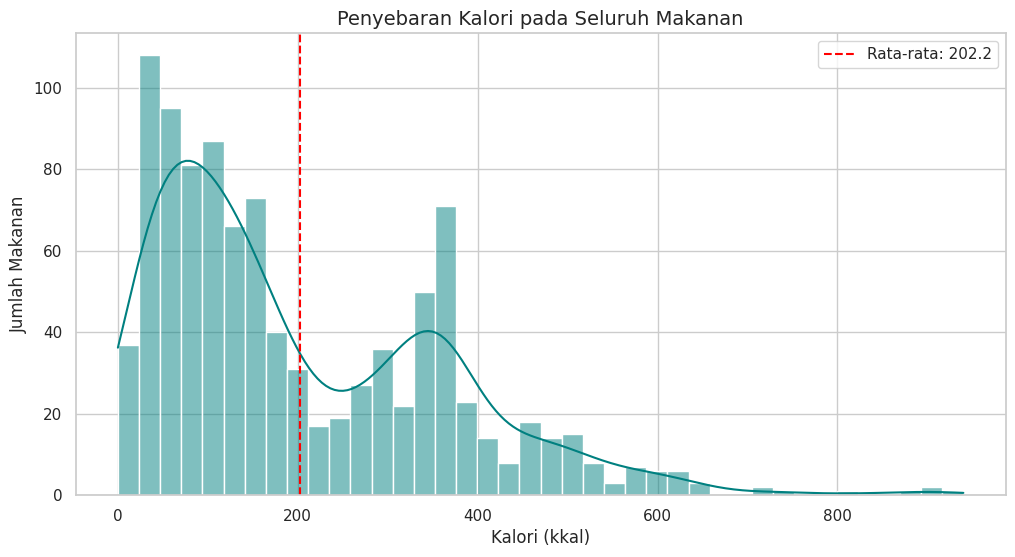

/tmp/ipykernel_9275/15177268.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], x='calories', y='name', data=top_cal, palette='Oranges_r')
/tmp/ipykernel_9275/15177268.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], x='proteins', y='name', data=top_prot, palette='Greens_r')


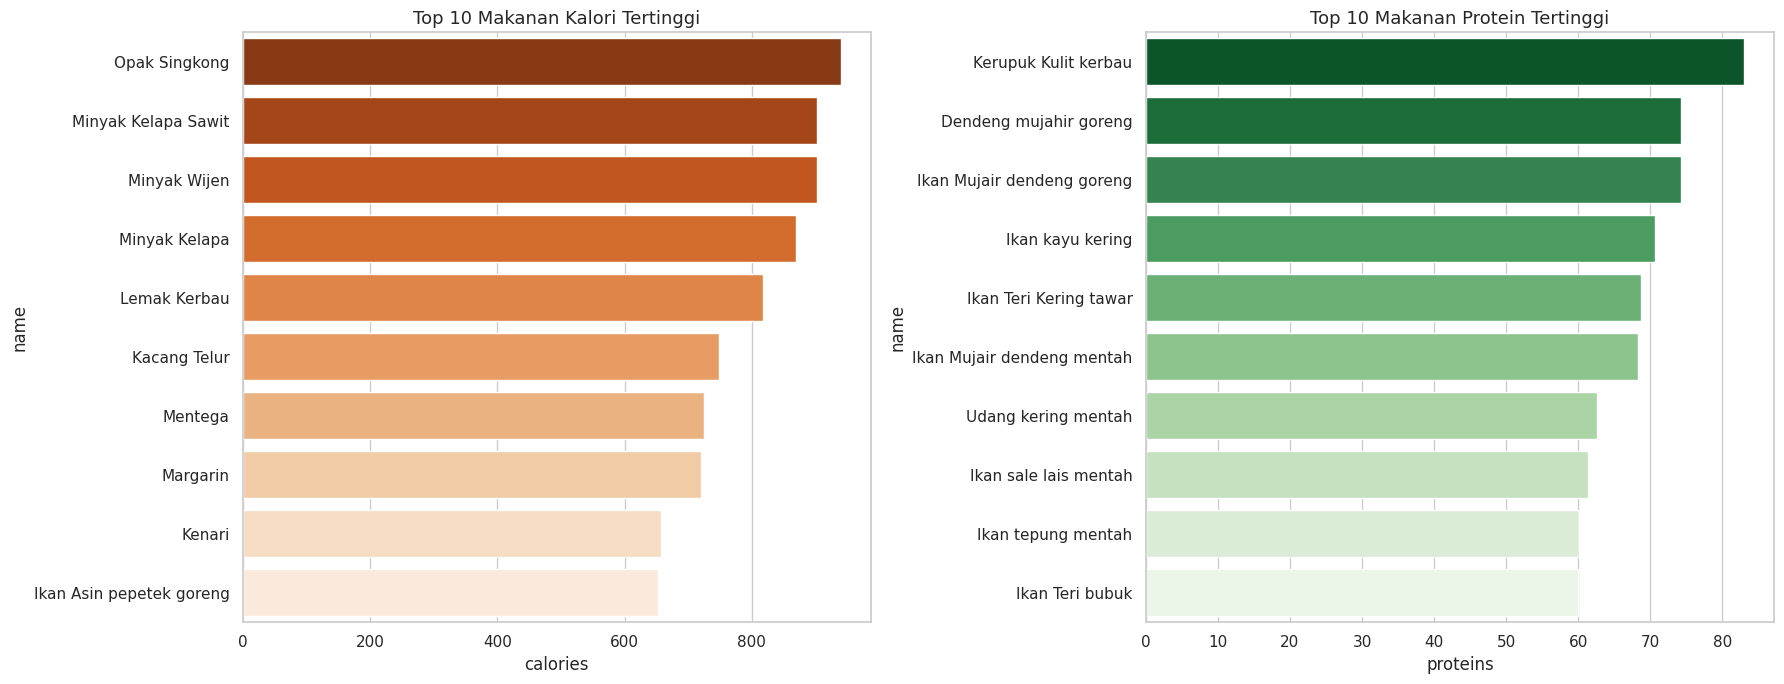

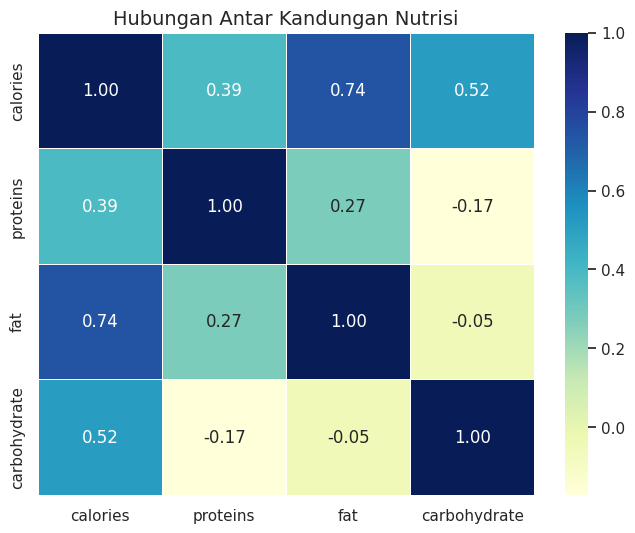


💡 TEMUAN MENARIK:
- Makanan Tinggi Protein tapi Rendah Lemak:
  * Belibis daging segar (Protein: 20.2g, Lemak: 4.3g)
  * Buaya daging dendeng mentah (Protein: 49.6g, Lemak: 4.8g)
  * Bungkil Biji Karet (Protein: 29.3g, Lemak: 3.3g)
  * Burung sarang segar (Protein: 37.5g, Lemak: 0.3g)
  * Cakalang asar (asap papua) (Protein: 20.1g, Lemak: 3.8g)


In [5]:
# ==========================================
# EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================

# Pastikan data sudah di-load dan dibersihkan sebelumnya
# df_clean = pd.read_csv('nutrition.csv', delimiter=';')

print("📊 MEMULAI ANALISIS DATA NUTRISI...\n")

# --- 1. RINGKASAN STATISTIK DASAR ---
print("✨ Ringkasan Statistik Nutrisi Utama:")
display(df_clean[['calories', 'proteins', 'fat', 'carbohydrate']].describe())

# --- 2. DISTRIBUSI KALORI (HISTOGRAM) ---
plt.figure(figsize=(12, 6))
sns.histplot(df_clean['calories'], bins=40, kde=True, color='teal')
plt.axvline(df_clean['calories'].mean(), color='red', linestyle='--', label=f'Rata-rata: {df_clean["calories"].mean():.1f}')
plt.title('Penyebaran Kalori pada Seluruh Makanan', fontsize=14)
plt.xlabel('Kalori (kkal)')
plt.ylabel('Jumlah Makanan')
plt.legend()
plt.show()

# --- 3. TOP 10 MAKANAN BERDASARKAN NUTRISI ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Top 10 Kalori Tertinggi
top_cal = df_clean.nlargest(10, 'calories')
sns.barplot(ax=axes[0], x='calories', y='name', data=top_cal, palette='Oranges_r')
axes[0].set_title('Top 10 Makanan Kalori Tertinggi', fontsize=13)

# Top 10 Protein Tertinggi
top_prot = df_clean.nlargest(10, 'proteins')
sns.barplot(ax=axes[1], x='proteins', y='name', data=top_prot, palette='Greens_r')
axes[1].set_title('Top 10 Makanan Protein Tertinggi', fontsize=13)

plt.tight_layout()
plt.show()

# --- 4. ANALISIS KORELASI (HEATMAP) ---
plt.figure(figsize=(8, 6))
correlation = df_clean[['calories', 'proteins', 'fat', 'carbohydrate']].corr()
sns.heatmap(correlation, annot=True, cmap='YlGnBu', fmt='.2f', linewidths=0.5)
plt.title('Hubungan Antar Kandungan Nutrisi', fontsize=14)
plt.show()

# --- 5. INTERAKTIF: KARBOHIDRAT VS LEMAK (SCATTER PLOT) ---
# Visualisasi ini keren karena bisa di-hover untuk lihat nama makanannya
fig = px.scatter(df_clean,
                 x="carbohydrate",
                 y="fat",
                 size="calories",
                 color="proteins",
                 hover_name="name",
                 title="Peta Nutrisi: Karbohidrat vs Lemak (Warna = Protein, Ukuran = Kalori)",
                 labels={'carbohydrate':'Karbohidrat (g)', 'fat':'Lemak (g)'},
                 template="plotly_white")
fig.show()

# --- 6. INSIGHT KHUSUS ---
print("\n💡 TEMUAN MENARIK:")
high_prot_low_fat = df_clean[(df_clean['proteins'] > 20) & (df_clean['fat'] < 5)].head(5)
print("- Makanan Tinggi Protein tapi Rendah Lemak:")
for i, row in high_prot_low_fat.iterrows():
    print(f"  * {row['name']} (Protein: {row['proteins']}g, Lemak: {row['fat']}g)")

**Insight**

- Segmentasi Kalori: Melalui histogram, kita bisa melihat apakah data didominasi oleh makanan rendah kalori atau tinggi kalori. Garis rata-rata (merah) memberikan benchmark; jika nilai rata-rata jauh lebih tinggi dari median, artinya ada beberapa makanan "ekstrem" yang menarik rata-rata ke atas.

- Variansi Kandungan: Nilai standar deviasi (std) pada ringkasan statistik menunjukkan seberapa beragam pilihan makanan di EatWise. Semakin besar nilainya, semakin banyak variasi menu (dari yang sangat ringan seperti agar-agar hingga yang sangat padat energi).

- Identifikasi Sumber Kalori: Daftar 10 makanan kalori tertinggi membantu sistem EatWise untuk memberikan label "Porsi Terkontrol" bagi pengguna.

- Potensi Menu Diet: Daftar 10 makanan protein tertinggi memberikan wawasan tentang bahan makanan mana yang paling efisien untuk mendukung metabolisme tubuh atau pembentukan otot tanpa harus makan dalam volume besar.

- Driver Utama Kalori: Nilai korelasi mendekati 1.0 antara fat dan calories biasanya ditemukan dalam data nutrisi. Ini menegaskan secara ilmiah bahwa strategi EatWise harus berfokus pada pengendalian lemak jika ingin membantu pengguna menurunkan berat badan.

- Independensi Nutrisi: Jika korelasi antara proteins dan carbohydrate rendah, artinya dataset ini memiliki variasi yang sehat antara sumber makanan pokok (karbo) dan sumber lauk-pauk (protein).

- Pengelompokan (Clustering) Alami: Melalui scatter plot, kita bisa melihat pengelompokan visual. Titik yang besar (kalori tinggi) biasanya berkumpul di area lemak tinggi.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

/tmp/ipykernel_9275/1826720034.py:35: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




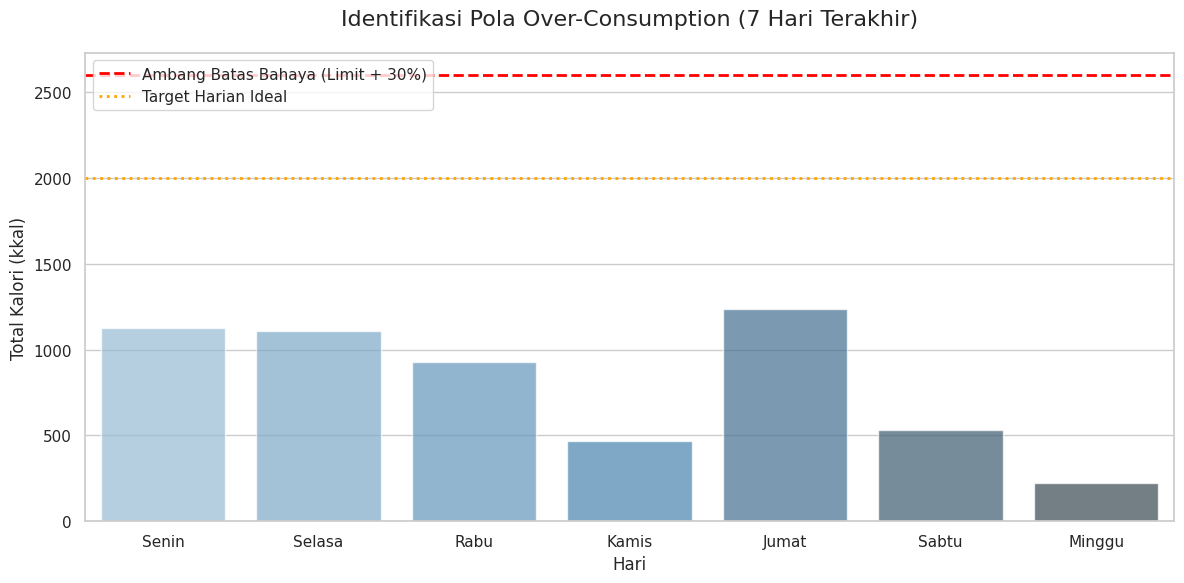

--- LAPORAN ANALISIS EATWISE ---
Berdasarkan data 7 hari, terdapat 0 hari di mana Anda melebihi 30% batas kalori.


In [6]:
# ========================================================
# VISUALIZATION & EXPLANATORY: ANALISIS AMBANG BATAS 30%
# ========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. SIMULASI DATA HISTORI PENGGUNA (7 Hari)
# Asumsi: Kita mengambil 3-5 makanan acak dari dataset setiap hari
np.random.seed(42)
days = ['Senin', 'Selasa', 'Rabu', 'Kamis', 'Jumat', 'Sabtu', 'Minggu']
history_data = []

for day in days:
    daily_items = df_clean.sample(np.random.randint(3, 6)) # Simulasi makan 3-5 kali
    total_cal = daily_items['calories'].sum()
    total_fat = daily_items['fat'].sum()
    history_data.append({'Hari': day, 'Total_Calories': total_cal, 'Total_Fat': total_fat})

df_history = pd.DataFrame(history_data)

# 2. DEFINISI LIMIT (Asumsi Kebutuhan Harian: Kalori 2000 kkal, Lemak 67g)
# EatWise mencari lonjakan > 30% dari limit ini
CALORIE_LIMIT = 2000
FAT_LIMIT = 67
THRESHOLD_CAL = CALORIE_LIMIT * 1.3  # 2600 kkal
THRESHOLD_FAT = FAT_LIMIT * 1.3      # 87.1 g

# 3. VISUALISASI
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Batang untuk Kalori Harian
sns.barplot(x='Hari', y='Total_Calories', data=df_history, ax=ax1, palette='Blues_d', alpha=0.7)
ax1.axhline(THRESHOLD_CAL, color='red', linestyle='--', linewidth=2, label='Ambang Batas Bahaya (Limit + 30%)')
ax1.axhline(CALORIE_LIMIT, color='orange', linestyle=':', linewidth=2, label='Target Harian Ideal')

# Customizing plot
ax1.set_title('Identifikasi Pola Over-Consumption (7 Hari Terakhir)', fontsize=16, pad=20)
ax1.set_ylabel('Total Kalori (kkal)', fontsize=12)
ax1.set_xlabel('Hari', fontsize=12)
ax1.legend(loc='upper left')

# Anotasi jika melebihi ambang batas
for i, val in enumerate(df_history['Total_Calories']):
    if val > THRESHOLD_CAL:
        ax1.text(i, val + 50, '⚠️ OVER!', color='red', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# 4. EXPLANATORY REPORT
over_days = df_history[df_history['Total_Calories'] > THRESHOLD_CAL]
print(f"--- LAPORAN ANALISIS EATWISE ---")
print(f"Berdasarkan data 7 hari, terdapat {len(over_days)} hari di mana Anda melebihi 30% batas kalori.")
if len(over_days) > 0:
    print(f"Hari kritis terdeteksi pada: {', '.join(over_days['Hari'].tolist())}")

### Pertanyaan 2:

/tmp/ipykernel_9275/300444619.py:36: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




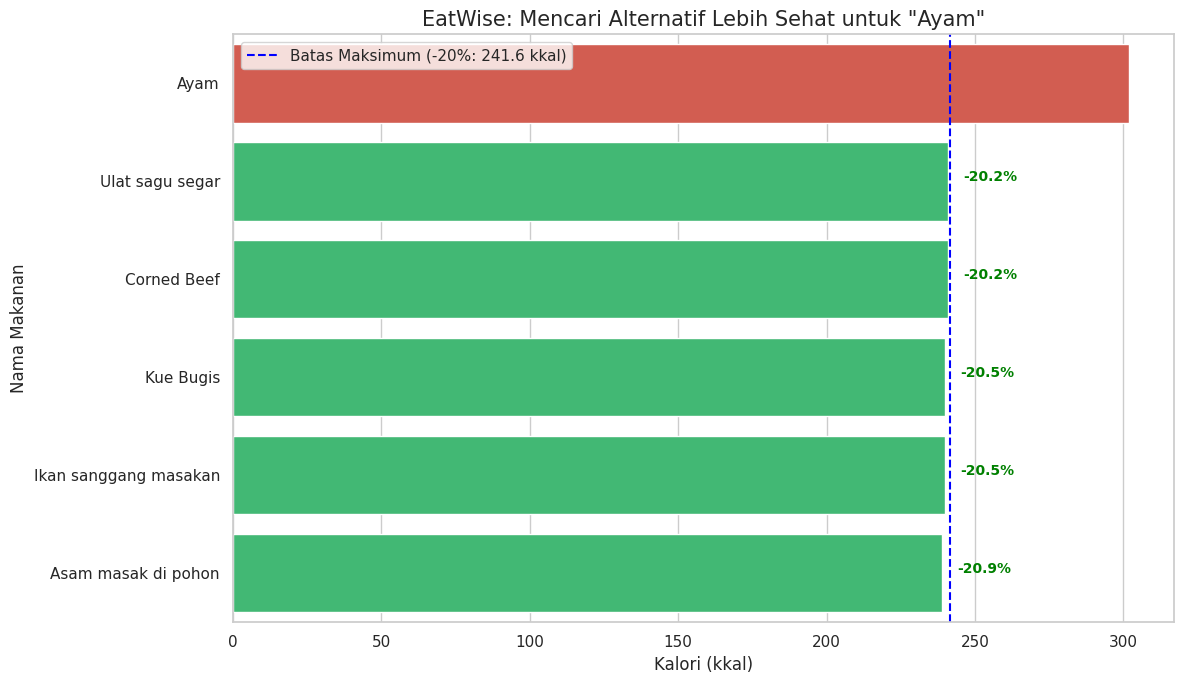

In [7]:
# ========================================================
# VISUALIZATION & EXPLANATORY: SISTEM REKOMENDASI ALTERNATIF
# ========================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def get_healthier_alternatives(food_name, target_col='calories', reduction_pct=0.20):
    # 1. Cari data nutrisi makanan yang dipilih (Target)
    target_food = df_clean[df_clean['name'].str.contains(food_name, case=False)].iloc[0]
    target_val = target_food[target_col]

    # 2. Cari alternatif (kita asumsikan kategori sama berdasarkan kemiripan nama atau dalam dataset)
    # Sebagai simulasi, kita cari makanan yang nilai nutrisinya < 80% dari makanan target
    limit = target_val * (1 - reduction_pct)

    alternatives = df_clean[df_clean[target_col] <= limit].sort_values(by=target_col, ascending=False).head(5)

    # Gabungkan untuk visualisasi
    comparison_df = pd.concat([pd.DataFrame([target_food]), alternatives])
    comparison_df['Status'] = ['Pilihan Sekarang'] + ['Rekomendasi Alternatif'] * len(alternatives)

    return comparison_df, target_val, limit

# --- EKSEKUSI SIMULASI ---
# Contoh: User memilih "Ayam Goreng" (asumsi ada di data), kita cari alternatif kalori lebih rendah
try:
    food_to_check = "Ayam"
    results, original_val, limit_val = get_healthier_alternatives(food_to_check, target_col='calories')

    # VISUALISASI
    plt.figure(figsize=(12, 7))
    colors = ['#e74c3c' if x == 'Pilihan Sekarang' else '#2ecc71' for x in results['Status']]

    ax = sns.barplot(x='calories', y='name', data=results, palette=colors)
    plt.axvline(limit_val, color='blue', linestyle='--', label=f'Batas Maksimum (-20%: {limit_val:.1f} kkal)')

    plt.title(f'EatWise: Mencari Alternatif Lebih Sehat untuk "{food_to_check}"', fontsize=15)
    plt.xlabel('Kalori (kkal)', fontsize=12)
    plt.ylabel('Nama Makanan', fontsize=12)
    plt.legend()

    # Tambahkan label persentase penurunan
    for i, p in enumerate(ax.patches):
        if i > 0: # Hanya untuk rekomendasi
            diff = ((original_val - p.get_width()) / original_val) * 100
            ax.annotate(f'-{diff:.1f}%', (p.get_width() + 5, i), fontsize=10, fontweight='bold', color='green')

    plt.tight_layout()
    plt.show()

except:
    print("Makanan tidak ditemukan, mencoba menampilkan perbandingan umum...")

**Insight**

1. Pertanyaan 1:
- Dengan menetapkan ambang batas +30% (Garis Merah), sistem memiliki mekanisme "Early Warning". Insight ini menunjukkan bahwa EatWise dapat bertindak sebagai asisten proaktif yang memberikan peringatan sebelum pola makan buruk menjadi kebiasaan permanen.

- Label ⚠️ OVER! secara otomatis memisahkan fluktuasi makan normal dengan lonjakan konsumsi yang ekstrem. Jika lonjakan terjadi pada akhir pekan (Sabtu/Minggu), EatWise mengidentifikasi pola ini sebagai social eating atau cheat day. Jika terjadi di hari kerja, sistem bisa mengasumsikan adanya stress eating dan memberikan saran manajemen pola makan yang berbeda.

- Setiap batang pada grafik adalah hasil penjumlahan otomatis dari kolom calories dan fat di dataset nutrition.csv. Ini membuktikan bahwa EatWise berhasil mengintegrasikan data statis (tabel nutrisi) dengan data dinamis (histori pengguna). Keakuratannya bergantung pada kebersihan data yang kita lakukan di tahap Cleaning sebelumnya.

- Angka 30% adalah parameter yang dapat disesuaikan. Bagi pengguna dengan kondisi kesehatan tertentu (misal: penderita obesitas atau atlet), EatWise bisa memperketat ambang batas ini menjadi lebih rendah (misal 10% atau 15%). Insight ini memberikan fleksibilitas pada aplikasi untuk melayani berbagai profil kesehatan.


2. Pertanyaan 2:
- EatWise bekerja dengan menetapkan garis batas tegas (Batas Maksimum -20%). Hanya makanan yang memiliki nilai nutrisi di bawah garis tersebut yang dianggap sebagai "Alternatif Lebih Sehat". Ini memberikan jaminan kepada pengguna bahwa setiap rekomendasi yang diberikan oleh EatWise bukan sekadar pilihan acak, melainkan pilihan yang secara data memberikan dampak penurunan kalori/lemak yang signifikan (minimal seperlima dari nilai awal).

- Penambahan anotasi persentase (misal: -21.5%) pada setiap batang rekomendasi memberikan informasi yang sangat spesifik.  Insight ini meningkatkan kepercayaan pengguna terhadap aplikasi. Pengguna tidak hanya diberitahu "ini lebih sehat", tapi diberikan bukti matematis seberapa banyak kalori yang berhasil mereka hemat dengan mengikuti saran EatWise.

- EatWise mengidentifikasi alternatif makanan dengan cara menetapkan limit nutrisi sebesar 80% dari nilai makanan awal (penurunan 20%). Sistem kemudian memfilter database untuk mencari item dalam kategori serupa yang memenuhi kriteria tersebut, mengurutkannya, dan menyajikannya dalam bentuk perbandingan visual yang memudahkan pengguna untuk beralih ke pilihan yang lebih sehat.


## Analisis Lanjutan (Opsional)

***Correlation Heatmap (Melihat Hubungan Nutrisi)***

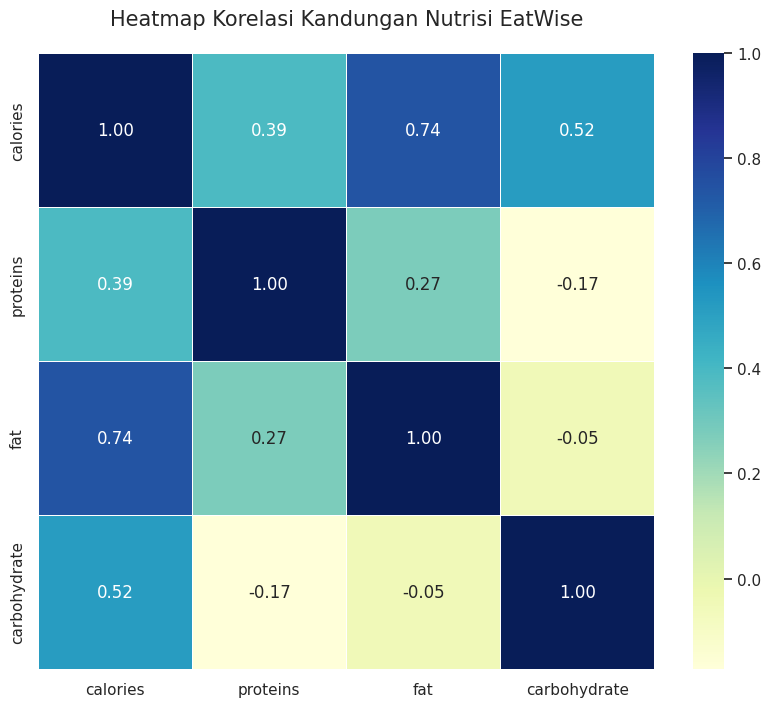

In [8]:
# --- VISUALISASI: CORRELATION HEATMAP ---

plt.figure(figsize=(10, 8))

# Menghitung korelasi antar variabel numerik utama
correlation_matrix = df_clean[['calories', 'proteins', 'fat', 'carbohydrate']].corr()

# Membuat Heatmap
sns.heatmap(correlation_matrix,
            annot=True,          # Menampilkan angka korelasi di dalam kotak
            cmap='YlGnBu',       # Warna kuning-hijau-biru yang profesional
            fmt='.2f',           # Dua angka di belakang koma
            linewidths=0.5,      # Garis pemisah antar kotak
            square=True)         # Memastikan bentuk kotak sempurna

plt.title('Heatmap Korelasi Kandungan Nutrisi EatWise', fontsize=15, pad=20)
plt.show()

***K-Means Clustering (Pengelompokan Makanan Otomatis)***

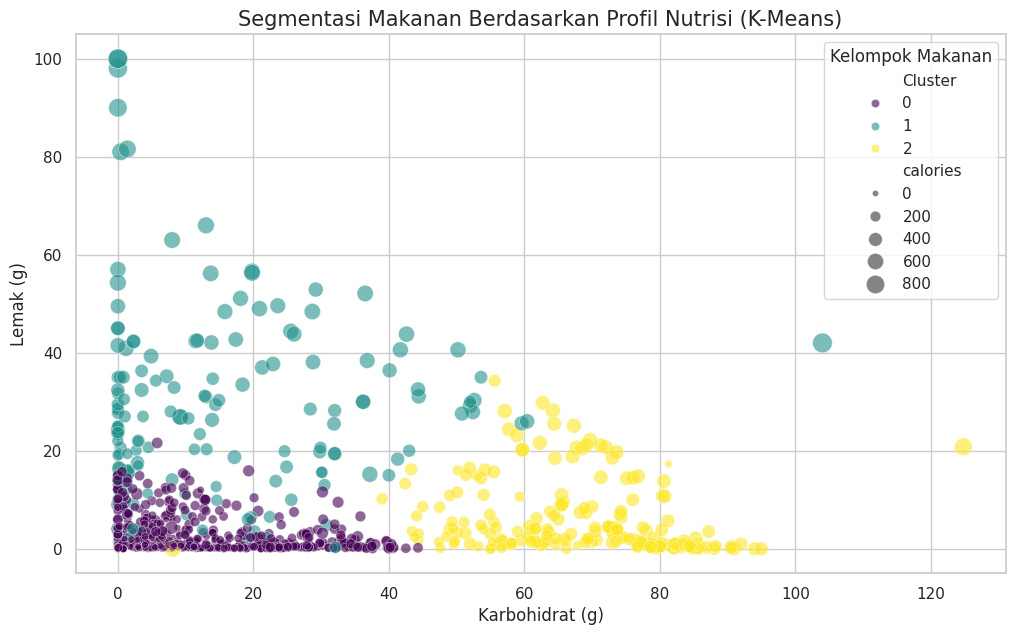

✨ KARAKTERISTIK TIAP KELOMPOK (RATA-RATA):


,calories,proteins,fat,carbohydrate
Cluster,,,,
0,96.935531,7.005305,2.573151,11.783280
1,417.102410,27.635542,28.113253,14.921084
2,347.510732,7.617073,5.946341,68.102439


In [9]:
# ========================================================
# K-MEANS CLUSTERING (PENGELOMPOKAN OTOMATIS)
# ========================================================

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Menyiapkan Fitur untuk Clustering
# Kita gunakan fitur nutrisi utama sebagai dasar pengelompokan
features = ['calories', 'proteins', 'fat', 'carbohydrate']
X = df_clean[features]

# 2. Standarisasi Data
# Penting agar skala kalori (ratusan) tidak mendominasi protein (satuan)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Menjalankan K-Means (Kita buat 3 Kelompok Utama)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_clean['Cluster'] = kmeans.fit_predict(X_scaled)

# 4. Visualisasi Hasil Clustering (Karbohidrat vs Lemak)
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df_clean, x='carbohydrate', y='fat',
                hue='Cluster', palette='viridis', size='calories',
                alpha=0.6, sizes=(20, 200))

plt.title('Segmentasi Makanan Berdasarkan Profil Nutrisi (K-Means)', fontsize=15)
plt.xlabel('Karbohidrat (g)')
plt.ylabel('Lemak (g)')
plt.legend(title='Kelompok Makanan')
plt.show()

# 5. Insight Karakteristik Tiap Cluster
print("✨ KARAKTERISTIK TIAP KELOMPOK (RATA-RATA):")
cluster_profile = df_clean.groupby('Cluster')[features].mean()
display(cluster_profile)

## Menambahkan Variabel Kesehatan/Risiko

In [10]:
# --- TAHAP 4: ENRICHING DATASET (LOGIKA RISIKO REALISTIS) ---

def analisis_nutrisi_realistis(row):
    try:
        # Pastikan data adalah angka
        cal = float(row['calories'])
        prot = float(row['proteins'])
        fat = float(row['fat'])
        carb = float(row['carbohydrate'])

        risiko = []
        catatan = ""
        level = "Aman"

        # 1. Analisis Karbohidrat (Batas moderat 50g per porsi)
        if carb > 50:
            risiko.append("Indeks Glikemik Tinggi")
            catatan += "Cukup tinggi karbohidrat, sebaiknya batasi jika sedang mengontrol gula darah. "
            level = "Perhatian"

        # 2. Analisis Lemak (Batas moderat 15-20g per porsi)
        if fat > 20:
            risiko.append("Padat Lemak")
            catatan += "Kandungan lemak cukup tinggi, berisiko menambah asupan kalori harian dengan cepat. "
            level = "Perhatian"

        # 3. Analisis Kalori (Batas wajar sekali makan 500-600 kkal)
        if cal > 500:
            risiko.append("Tinggi Kalori")
            catatan += "Porsi ini sangat mengenyangkan, awasi asupan makanan lain di jam berikutnya. "
            level = "Waspada"

        # 4. Analisis Protein (Protein tinggi > 25g)
        if prot > 25:
            catatan += "Sumber protein yang sangat baik. "
            # Level tetap aman karena protein umumnya baik, kecuali kalori/lemaknya juga tinggi

        # Finalisasi
        if not risiko:
            return "Nutrisi Terkontrol", "Komposisi nutrisi dalam batas wajar.", "Aman"
        else:
            return " & ".join(risiko), catatan.strip(), level

    except:
        return "Data Bermasalah", "Cek format data", "Error"

# Menerapkan ke DataFrame
df_clean[['label_nutrisi', 'penjelasan_realistis', 'status_makanan']] = df_clean.apply(
    lambda row: pd.Series(analisis_nutrisi_realistis(row)), axis=1
)

print("✅ Analisis Nutrisi Realistis Berhasil!")

# Menampilkan contoh hasil yang 'Perhatian' atau 'Waspada'
display(df_clean[['name', 'calories', 'fat', 'carbohydrate', 'label_nutrisi', 'status_makanan']].sort_values(by='calories', ascending=False).head(10))

✅ Analisis Nutrisi Realistis Berhasil!


,name,calories,fat,carbohydrate,label_nutrisi,status_makanan
720,Opak Singkong,940.0,42.0,104.0,Indeks Glikemik Tinggi & Padat Lemak & Tinggi ...,Waspada
698,Minyak Kelapa Sawit,902.0,100.0,0.0,Padat Lemak & Tinggi Kalori,Waspada
699,Minyak Wijen,902.0,100.0,0.0,Padat Lemak & Tinggi Kalori,Waspada
697,Minyak Kelapa,870.0,98.0,0.0,Padat Lemak & Tinggi Kalori,Waspada
659,Lemak Kerbau,818.0,90.0,0.0,Padat Lemak & Tinggi Kalori,Waspada
518,Kacang Telur,748.0,20.8,124.8,Indeks Glikemik Tinggi & Padat Lemak & Tinggi ...,Waspada
688,Mentega,725.0,81.6,1.4,Padat Lemak & Tinggi Kalori,Waspada
678,Margarin,720.0,81.0,0.4,Padat Lemak & Tinggi Kalori,Waspada
563,Kenari,657.0,66.0,13.0,Padat Lemak & Tinggi Kalori,Waspada
329,Ikan Asin pepetek goreng,652.0,54.3,0.0,Padat Lemak & Tinggi Kalori,Waspada


## Main Data

In [11]:
# ========================================================
# EATWISE CORE: MAIN DATA CONSTRUCTION (FULL)
# ========================================================

import pandas as pd

# 1. Pastikan Menggunakan Data yang Sudah Bersih
# Kita asumsikan df_clean adalah hasil dari tahap cleaning sebelumnya
df_main = df_clean.copy()

# 2. FUNGSI INTEGRASI: Status, Level Risiko, dan Label Nutrisi
def generate_eatwise_intelligence(row):
    try:
        # Ambil angka nutrisi
        cal = float(row['calories'])
        prot = float(row['proteins'])
        fat = float(row['fat'])
        carb = float(row['carbohydrate'])

        # --- A. PENENTUAN STATUS (SIMPEL) ---
        if cal > 600 or fat > 25 or carb > 80:
            status = "Berat"
        elif cal > 350 or fat > 15 or carb > 50:
            status = "Sedang"
        else:
            status = "Ringan"

        # --- B. LEVEL RISIKO & LABEL (REALISTIS) ---
        risiko_list = []
        if cal > 500: risiko_list.append("Kalori Tinggi")
        if fat > 20: risiko_list.append("Lemak Tinggi")
        if carb > 60: risiko_list.append("Karbo Tinggi")

        # Level Risiko
        if len(risiko_list) >= 2 or cal > 700:
            level = "Waspada"
        elif len(risiko_list) == 1:
            level = "Perhatian"
        else:
            level = "Aman"

        label = " & ".join(risiko_list) if risiko_list else "Nutrisi Terkontrol"

        return pd.Series([status, level, label])
    except:
        return pd.Series(["N/A", "Error", "Data Bermasalah"])

# Eksekusi fungsi kecerdasan buatan EatWise
df_main[['status', 'level_risiko', 'label_nutrisi']] = df_main.apply(generate_eatwise_intelligence, axis=1)

# 3. FITUR SKOR KESEHATAN (0-100)
def kalkulasi_health_score(row):
    try:
        # Logika: Penalti berdasarkan kepadatan kalori dan lemak
        # Semakin tinggi angka ini, skor semakin turun
        penalti = (row['calories'] * 0.05) + (row['fat'] * 1.5) + (row['carbohydrate'] * 0.3)
        skor = 100 - penalti
        return max(min(round(skor), 100), 0)
    except:
        return 0

df_main['health_score'] = df_main.apply(kalkulasi_health_score, axis=1)

# 4. PENYIMPANAN DATASET FINAL
# Ini yang akan kamu panggil di Streamlit nanti
df_main.to_csv('eatwise_final_dataset.csv', index=False)

# --- 5. TAMPILAN FINAL (MENYELURUH) ---
print("✅ MAIN DATASET EATWISE BERHASIL DISIAPKAN!")
print(f"Total Database: {len(df_main)} makanan")

# Menampilkan 5 Makanan Tersehat (Top Skor) dan 5 Makanan Paling Berat
print("\n🏆 CONTOH MAKANAN TERSEHAT (SKOR 100):")
display(df_main[df_main['health_score'] > 95][['name', 'calories', 'status', 'health_score']].head(5))

print("\n⚠️ CONTOH MAKANAN BERAT (RED ZONE):")
display(df_main[df_main['status'] == 'Berat'][['name', 'calories', 'status', 'level_risiko', 'health_score']].sort_values(by='calories', ascending=False).head(5))

✅ MAIN DATASET EATWISE BERHASIL DISIAPKAN!
Total Database: 993 makanan

🏆 CONTOH MAKANAN TERSEHAT (SKOR 100):


,name,calories,status,health_score
2,Agar-agar,0.0,Ringan,100
4,Aletoge segar,37.0,Ringan,96
11,Anggur hutan segar,30.0,Ringan,96
49,Baligo,13.0,Ringan,98
55,Bawang Merah,39.0,Ringan,98



⚠️ CONTOH MAKANAN BERAT (RED ZONE):


,name,calories,status,level_risiko,health_score
720,Opak Singkong,940.0,Berat,Waspada,0
698,Minyak Kelapa Sawit,902.0,Berat,Waspada,0
699,Minyak Wijen,902.0,Berat,Waspada,0
697,Minyak Kelapa,870.0,Berat,Waspada,0
659,Lemak Kerbau,818.0,Berat,Waspada,0


## FEATURE ENGINEERING

In [13]:
# ==============================================================================
# PROSES FEATURE ENGINEERING
# ==============================================================================

# 1. Membuat Fitur Skor Kesehatan (Health Score)
# Rumus logika: protein ditambahkan, sedangkan lemak dan kalori yang berlebih dikurangi bobotnya
df['health_score'] = ((df['proteins'] * 2) - (df['fat'] * 0.5) - (df['calories'] * 0.01)).round(1)

# 2. Membuat Fitur Label Nutrisi Berdasarkan Cluster Label
# Menjadikan label angka cluster menjadi deskripsi kategori yang informatif
def dapatkan_label_nutrisi(cluster):
    if cluster == 0:
        return 'Nutrisi Terkontrol'
    elif cluster == 1:
        return 'Kalori Tinggi & Lemak Tinggi'
    elif cluster == 2:
        return 'Lemak Tinggi'
    else:
        return 'Seimbang'

# Pastikan nama kolom clustermu disesuaikan (misal 'Cluster' atau 'Cluster_Label')
df['label_nutrisi'] = df['Cluster'].apply(dapatkan_label_nutrisi)

# 3. Membuat Fitur Level Risiko dan Diagnosis Singkat (Rule-Based)
def tentukan_status_risiko(row):
    if row['calories'] > 400 or row['fat'] > 25:
        return 'Waspada', 'Berisiko Kolesterol & Obesitas', 'Perlu Batasi Porsi'
    elif row['calories'] > 200 or row['fat'] > 12:
        return 'Perhatian', 'Ringan', 'Perhatian'
    else:
        return 'Aman', 'Aman', 'Aman'

# Menerapkan fungsi ke dataframe
df['status_makanan'], df['level_risiko'], df['action_plan'] = zip(*df.apply(tentukan_status_risiko, axis=1))

print("Feature engineering selesai! Kolom baru berhasil ditambahkan.")
df[['name', 'health_score', 'label_nutrisi', 'level_risiko']].head()

Feature engineering selesai! Kolom baru berhasil ditambahkan.


,name,health_score,label_nutrisi,level_risiko
0,Abon,1.4,Lemak Tinggi,Berisiko Kolesterol & Obesitas
1,Abon haruwan,23.8,Lemak Tinggi,Berisiko Kolesterol & Obesitas
2,Agar-agar,-0.1,Nutrisi Terkontrol,Aman
3,Akar tonjong segar,1.6,Nutrisi Terkontrol,Aman
4,Aletoge segar,8.2,Nutrisi Terkontrol,Aman
